# Solving RL Problems: Defining States, Actions, and Rewards

## Learning Objectives

By the end of this notebook, you will be able to:
- define a state space for a simple RL problem
- define valid actions for an agent
- design a reward function that encourages the right behavior
- explain why bad reward design can create bad learning
- run a simple interaction loop before using a full RL algorithm

## Prerequisites

Before starting:
- complete `04_openai_gym_setup.ipynb`
- understand the basic RL loop: state -> action -> reward -> next state
- be comfortable reading simple Python functions

## Why this notebook matters

Before choosing any algorithm, you must first decide:

1. What should the agent observe?
2. What can the agent do?
3. What should count as success or failure?

If these are designed poorly, even a strong RL algorithm can learn the wrong thing.

## Lesson Brief

This lesson teaches students how to **formulate** a reinforcement learning problem correctly.

The focus is not on fancy algorithms, but on making good choices for states, actions, and rewards so that learning becomes possible.

Why this matters: many RL failures come from bad problem formulation, not from bad algorithms.

This notebook helps students think like environment designers, not just code writers.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **Nicholas Renotte - "Reinforcement Learning in 3 Hours | Full Course using Python"**:
[Watch on YouTube](https://www.youtube.com/watch?v=Mut_u40Sqz4)

Suggested focus: the early section starting around **04:24** for agent, environment, actions, observations, and rewards.

Why this pick:
- beginner-friendly explanations.
- Strong overview of the RL formulation before algorithms become the focus.
- Useful when students need help thinking about how to define a problem correctly.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- State design: what the agent must know.
- Action design: what the agent is allowed to do.
- Reward design: what the agent is pushed toward.
- Representation: how the task is encoded.

### Quick Check
- How can a weak state design break learning?
- Why can a bad reward ruin a good algorithm?
- What makes an action space realistic?

### Common Mistakes
- Blaming the algorithm when formulation is poor.
- Using rewards that do not match the real goal.
- Adding unnecessary actions or state details.


## Quick Check Before You Begin

Make sure you can answer these questions:

1. Is a **state** the same thing as the real world itself?
2. Can a reward function accidentally encourage the wrong behavior?
3. Why do we need an interaction loop before training an agent?

If not, slow down and answer them before moving on.


### Step Guide

**What this cell does:** `%pip` installs helpers, then imports NumPy/Matplotlib for the design exercises below.

**How to read it (weak Python OK):** Treat as setup—success means “no red traceback.”

**What to expect in the output:** Pip chatter and a short confirmation print.

**If you feel lost:** Fix installs here before any simulation cells.


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.

# Line magic: Jupyter/IPython directive for this line only.
%pip install "gymnasium[classic-control]" numpy matplotlib ipywidgets pillow -q
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt
# Load a library so you can use its ready-made functions and types below.
import gymnasium as gym

# Readable defaults for plots in this notebook (matches other Unit 1 examples).
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        pass
plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

# Show text or numbers in the cell output area under the code.
print("✅ Libraries imported!")
# Show text or numbers in the cell output area under the code.
print("\nSolving RL Problems: States, Actions, and Rewards")
# Show text or numbers in the cell output area under the code.
print("=" * 60)


Note: you may need to restart the kernel to use updated packages.
✅ Libraries imported!

Solving RL Problems: States, Actions, and Rewards


## Part 1: Defining State Spaces


### Step Guide

**What this cell does:** **Part 1** — defines several **state representations** (full info vs partial observations) for the same toy problems.

**How to read it (weak Python OK):** Ask for each example: “What does the agent actually get to see each step?”

**What to expect in the output:** Printed descriptions of different state vectors.

**If you feel lost:** Copy one “good” and one “bad” state design into your notes side by side—the contrast is the lesson.


In [2]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 1: Defining State Spaces")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Save a value in a name so the next lines can read it.
examples = {
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "Grid navigation": {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "good_state": "(row, col) position of the agent",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "too_small": "only row",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "too_large": "every detail of the whole computer screen",
    # Execute: },
    },
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "CartPole": {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "good_state": "cart position, cart velocity, pole angle, pole angular velocity",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "too_small": "pole angle only",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "too_large": "full rendered image when not needed for this level",
    # Execute: },
    },
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "Inventory control": {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "good_state": "current stock level and maybe demand signal",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "too_small": "stock level from yesterday only",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "too_large": "every warehouse detail regardless of relevance",
    # Execute: },
    },
# Part of a dict/set literal layout (syntax grouping).
}

# Start a loop: repeat the indented block once per item in the sequence.
for problem, details in examples.items():
    # Show text or numbers in the cell output area under the code.
    print(f"\n{problem}")
    # Show text or numbers in the cell output area under the code.
    print(" Good state representation:", details["good_state"])
    # Show text or numbers in the cell output area under the code.
    print(" Too small:", details["too_small"])
    # Show text or numbers in the cell output area under the code.
    print(" Too large:", details["too_large"])

# Show text or numbers in the cell output area under the code.
print("\nCheckpoint: a useful state contains enough information for decision-making,")
# Show text or numbers in the cell output area under the code.
print("but not so much unnecessary detail that the problem becomes harder to learn.")


Part 1: Defining State Spaces

Grid navigation
 Good state representation: (row, col) position of the agent
 Too small: only row
 Too large: every detail of the whole computer screen

CartPole
 Good state representation: cart position, cart velocity, pole angle, pole angular velocity
 Too small: pole angle only
 Too large: full rendered image when not needed for this level

Inventory control
 Good state representation: current stock level and maybe demand signal
 Too small: stock level from yesterday only
 Too large: every warehouse detail regardless of relevance

Checkpoint: a useful state contains enough information for decision-making,
but not so much unnecessary detail that the problem becomes harder to learn.


## Part 2: Defining Action Spaces


### Step Guide

**What this cell does:** **Part 2** — compares **discrete vs continuous action spaces** and when each makes sense.

**How to read it (weak Python OK):** Link actions to hardware: keyboard taps vs steering wheel angles.

**What to expect in the output:** Textual comparisons and small numeric demos.

**If you feel lost:** Write one sentence per world: “Actions here are ___ because ___.”


In [3]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 2: Defining Action Spaces")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# CartPole actions
# Save a value in a name so the next lines can read it.
env = gym.make("CartPole-v1")
# Show text or numbers in the cell output area under the code.
print("\nCartPole-v1")
# Show text or numbers in the cell output area under the code.
print(f" Action space: {env.action_space}")
# Show text or numbers in the cell output area under the code.
print(" Valid actions:")
# Show text or numbers in the cell output area under the code.
print(" 0 -> push cart left")
# Show text or numbers in the cell output area under the code.
print(" 1 -> push cart right")

# FrozenLake actions
# Save a value in a name so the next lines can read it.
env_fl = gym.make("FrozenLake-v1")
# Another assignment—same idea: store a value for the lines below.
obs_fl, info = env_fl.reset()
# Show text or numbers in the cell output area under the code.
print("\nFrozenLake-v1")
# Show text or numbers in the cell output area under the code.
print(f" Action space: {env_fl.action_space}")
# Show text or numbers in the cell output area under the code.
print(" Valid actions:")
# Show text or numbers in the cell output area under the code.
print(" 0 -> left")
# Show text or numbers in the cell output area under the code.
print(" 1 -> down")
# Show text or numbers in the cell output area under the code.
print(" 2 -> right")
# Show text or numbers in the cell output area under the code.
print(" 3 -> up")

# Execute: env.close()
env.close()
# Execute: env_fl.close()
env_fl.close()

# Show text or numbers in the cell output area under the code.
print("\nAction-space design rules:")
# Show text or numbers in the cell output area under the code.
print("- The actions must be valid choices the agent can actually take.")
# Show text or numbers in the cell output area under the code.
print("- Too few actions makes the agent powerless.")
# Show text or numbers in the cell output area under the code.
print("- Too many unnecessary actions makes learning harder.")



Part 2: Defining Action Spaces

CartPole-v1
 Action space: Discrete(2)
 Valid actions:
 0 -> push cart left
 1 -> push cart right

FrozenLake-v1
 Action space: Discrete(4)
 Valid actions:
 0 -> left
 1 -> down
 2 -> right
 3 -> up

Action-space design rules:
- The actions must be valid choices the agent can actually take.
- Too few actions makes the agent powerless.
- Too many unnecessary actions makes learning harder.


## Part 3: Designing Reward Functions


### Step Guide

**What this cell does:** **Part 3** — reward shaping demos (sparse vs dense, penalties, shaping traps).

**How to read it (weak Python OK):** For each reward tweak ask: “Does this number push the agent toward the real goal, or toward a shortcut?”

**What to expect in the output:** Totals or tables showing how different rewards change behavior summaries.

**If you feel lost:** Ignore fancy terms—only track whether rewards go up when the agent does the right human-level thing.



Part 3: Designing Reward Functions

Task: Maze goal
 Reward design: +10 for goal, -1 per move, -10 for falling into a trap
 Likely effect: Encourages fast and safe navigation

Task: CartPole
 Reward design: +1 per balanced step
 Likely effect: Encourages keeping the pole upright longer

Task: Bad driving reward
 Reward design: +100 for speed only
 Likely effect: May encourage unsafe driving and crashes

Reward-design checklist:
- Does the reward reflect the real goal?
- Can the agent exploit the reward without solving the task?
- Does the reward encourage safe and sensible behavior?


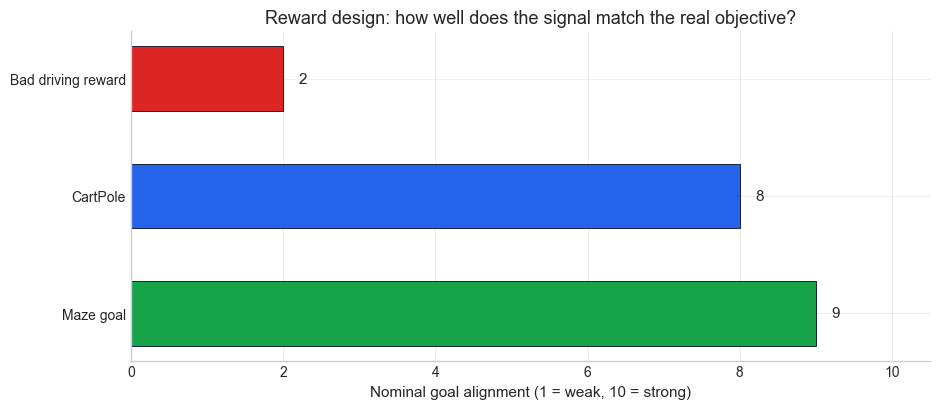

In [4]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 3: Designing Reward Functions")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Unpack the one-step model output from transition(state, action).
reward_examples = [
    # Execute: ("Maze goal", "+10 for goal, -1 per move, -10 for falling into a trap", "Encourages fast a …
    ("Maze goal", "+10 for goal, -1 per move, -10 for falling into a trap", "Encourages fast and safe navigation"),
    # Execute: ("CartPole", "+1 per balanced step", "Encourages keeping the pole upright longer"),
    ("CartPole", "+1 per balanced step", "Encourages keeping the pole upright longer"),
    # Execute: ("Bad driving reward", "+100 for speed only", "May encourage unsafe driving and crashes"),
    ("Bad driving reward", "+100 for speed only", "May encourage unsafe driving and crashes"),
# Execute: ]
]

# Start a loop: repeat the indented block once per item in the sequence.
for task, reward_design, effect in reward_examples:
    # Show text or numbers in the cell output area under the code.
    print(f"\nTask: {task}")
    # Show text or numbers in the cell output area under the code.
    print(" Reward design:", reward_design)
    # Show text or numbers in the cell output area under the code.
    print(" Likely effect:", effect)

# Show text or numbers in the cell output area under the code.
print("\nReward-design checklist:")
# Show text or numbers in the cell output area under the code.
print("- Does the reward reflect the real goal?")
# Show text or numbers in the cell output area under the code.
print("- Can the agent exploit the reward without solving the task?")
# Show text or numbers in the cell output area under the code.
print("- Does the reward encourage safe and sensible behavior?")

# Visual: nominal "goal alignment" scores for classroom discussion (illustrative, not from simulation).
alignment_scores = {"Maze goal": 9, "CartPole": 8, "Bad driving reward": 2}
fig, ax = plt.subplots(figsize=(9.5, 4.2))
task_labels = [row[0] for row in reward_examples]
heights = [alignment_scores[name] for name in task_labels]
colors = ["#16a34a", "#2563eb", "#dc2626"]
ax.barh(task_labels, heights, color=colors, height=0.55, edgecolor="#0f172a", linewidth=0.65)
ax.set_xlim(0, 10.5)
ax.set_xlabel("Nominal goal alignment (1 = weak, 10 = strong)")
ax.set_title("Reward design: how well does the signal match the real objective?")
ax.grid(True, axis="x", alpha=0.35)
for y, h in enumerate(heights):
    ax.text(h + 0.2, y, str(h), va="center", fontsize=11)
plt.tight_layout()
plt.show()


## Part 4: Running RL Simulations


### Step Guide

**What this cell does:** **Part 4** — ties the design choices to **simple simulations** so you see consequences, not just definitions.

**How to read it (weak Python OK):** Read outputs like lab measurements: what went better when the design improved?

**What to expect in the output:** Short simulation logs or aggregate scores.

**If you feel lost:** Pick one metric (average return, success rate) and only watch that number across runs.



Part 4: Running RL Simulations
Starting state: 0
Step 1: state=0, action=3, next_state=0, reward=0.0, terminated=False, truncated=False
Step 2: state=0, action=2, next_state=1, reward=0.0, terminated=False, truncated=False
Step 3: state=1, action=3, next_state=1, reward=0.0, terminated=False, truncated=False
Step 4: state=1, action=0, next_state=0, reward=0.0, terminated=False, truncated=False
Step 5: state=0, action=0, next_state=0, reward=0.0, terminated=False, truncated=False
Step 6: state=0, action=1, next_state=4, reward=0.0, terminated=False, truncated=False
Step 7: state=4, action=3, next_state=0, reward=0.0, terminated=False, truncated=False
Step 8: state=0, action=0, next_state=0, reward=0.0, terminated=False, truncated=False


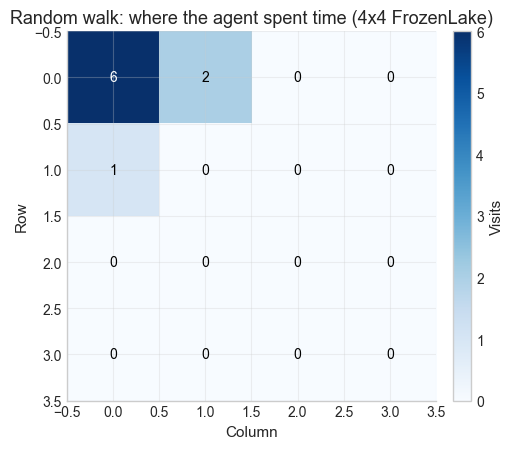


Total reward collected in this random simulation: 0.0
This is the full interaction loop that later algorithms will use repeatedly.


In [5]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 4: Running RL Simulations")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Save a value in a name so the next lines can read it.
env = gym.make("FrozenLake-v1", is_slippery=False)
# Another assignment—same idea: store a value for the lines below.
obs, info = env.reset(seed=7)
# Another assignment—same idea: store a value for the lines below.
total_reward = 0
# Count visits per cell for a 4x4 grid heatmap (helps students "see" the walk).
visit_counts = np.zeros((4, 4), dtype=float)
r, c = divmod(int(obs), 4)
visit_counts[r, c] += 1

# Show text or numbers in the cell output area under the code.
print("Starting state:", obs)
# Start a loop: repeat the indented block once per item in the sequence.
for step_idx in range(8):
    # Save a value in a name so the next lines can read it.
    action = env.action_space.sample()
    # Another assignment—same idea: store a value for the lines below.
    next_obs, reward, terminated, truncated, info = env.step(action)
    # Another assignment—same idea: store a value for the lines below.
    total_reward += reward
    # Show text or numbers in the cell output area under the code.
    print(
        # Build text with {…} holes filled in by variables (an f-string).
        f"Step {step_idx + 1}: state={obs}, action={action}, next_state={next_obs}, "
        # Build text with {…} holes filled in by variables (an f-string).
        f"reward={reward}, terminated={terminated}, truncated={truncated}"
    # Close the parentheses opened earlier (end this function call / grouping).
    )
    # Save a value in a name so the next lines can read it.
    obs = next_obs
    r2, c2 = divmod(int(obs), 4)
    visit_counts[r2, c2] += 1
    # If the condition is True, run the indented block under this line.
    if terminated or truncated:
        # Show text or numbers in the cell output area under the code.
        print("Episode ended. Reset would be needed before a new run.")
        # Stop the loop completely and continue after the loop block.
        break

# Execute: env.close()
env.close()

fig, ax = plt.subplots(figsize=(5.2, 4.6))
im = ax.imshow(visit_counts, cmap="Blues", interpolation="nearest")
ax.set_title("Random walk: where the agent spent time (4x4 FrozenLake)")
ax.set_xlabel("Column")
ax.set_ylabel("Row")
for (j, i), v in np.ndenumerate(visit_counts):
    ax.text(i, j, int(v), ha="center", va="center", color="white" if v > visit_counts.max() / 2 else "black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Visits")
plt.tight_layout()
plt.show()

# Show text or numbers in the cell output area under the code.
print("\nTotal reward collected in this random simulation:", total_reward)
# Show text or numbers in the cell output area under the code.
print("This is the full interaction loop that later algorithms will use repeatedly.")


## Part 4b: Watch FrozenLake move (GIF + step slider)

**Part 4** printed transitions as text. This section shows the **same kind of loop** as **grid images** so you can connect `state`, `action`, and `reward` to what you see.

The policy here is **random** (exploration only) — the goal is to practice reading the **environment interface**, not to show a trained agent yet.

Note: you may need to restart the kernel to use updated packages.
Frames: 7 | return=0.0 | terminated=True | truncated=False


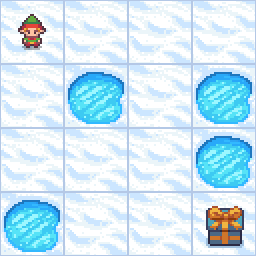

In [6]:
# rgb_array replay for FrozenLake (same is_slippery=False setting as Part 4).

%pip install ipywidgets pillow -q

import pathlib
import sys

for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError("Could not find course09_step_viz.py — run from inside Course 09.")

if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import course09_step_viz as cs9viz

# Same alias as earlier cells — keeps this block runnable if you jump here directly.
import gymnasium as gym

env_vis = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")


def random_policy(obs, step):
    return int(env_vis.action_space.sample())


frames, total_r, term, trunc = cs9viz.collect_rollout_frames(
    env_vis, random_policy, max_steps=35, seed=11
)
env_vis.close()

print(f"Frames: {len(frames)} | return={total_r} | terminated={term} | truncated={trunc}")
cs9viz.display_gif(frames, duration_ms=200)
cs9viz.display_step_slider(frames, title="FrozenLake-v1 timestep")

## Worked Example: From Business Problem to RL Formulation

Suppose you want to manage inventory in a small store.

A useful RL formulation could be:

- **State:** current stock level
- **Action:** reorder or do not reorder
- **Reward:** sales profit minus shortage penalty minus restocking cost

This is a good teaching example because students can clearly see how state,
action, and reward connect to a real decision problem.

### Step Guide

**What this cell does:** Re-imports/plugs in plotting helpers after the conceptual sections (same tool belt pattern).

**How to read it (weak Python OK):** Another import cell—skim if the earlier parts already ran.

**What to expect in the output:** Usually silent.

**If you feel lost:** If you see `NameError` later, come back and run this cell.


Starting stock level: 3
Day 1: action='do not reorder', demand=3, next_state=0, reward=3.0
Day 2: action='do not reorder', demand=2, next_state=0, reward=-2.0
Day 3: action='do not reorder', demand=3, next_state=0, reward=-2.0
Day 4: action='do not reorder', demand=0, next_state=0, reward=0.0
Day 5: action='do not reorder', demand=1, next_state=0, reward=-2.0


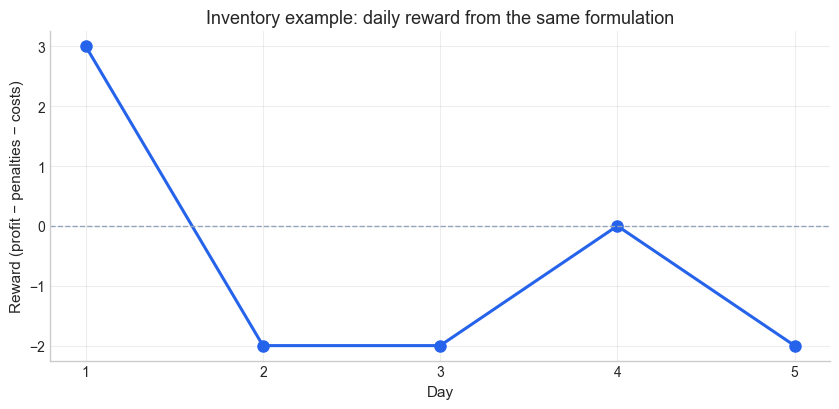


Teaching point:
This example is not about advanced RL yet.
It is about translating a real problem into states, actions, and rewards.


In [7]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)

# Save a value in a name so the next lines can read it.
MAX_STOCK = 10
# Create the list of action names (their indices are the numeric action ids).
ACTIONS = {0: "do not reorder", 1: "reorder 5 units"}


# Function `inventory_step` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: state, action.
def inventory_step(state, action):
    # Save a value in a name so the next lines can read it.
    stock = min(state + (5 if action == 1 else 0), MAX_STOCK)
    # Another assignment—same idea: store a value for the lines below.
    demand = np.random.randint(0, 4)
    # Another assignment—same idea: store a value for the lines below.
    sold = min(stock, demand)
    # Another assignment—same idea: store a value for the lines below.
    shortage_penalty = 2 if demand > stock else 0
    # Another assignment—same idea: store a value for the lines below.
    reorder_cost = 0.5 if action == 1 else 0.0
    # Unpack the one-step model output from transition(state, action).
    reward = sold - shortage_penalty - reorder_cost
    # Unpack the one-step model output from transition(state, action).
    next_state = max(stock - demand, 0)
    # Send a value back to whoever called this function.
    return next_state, reward, demand


# Create or choose a variable used in the Bellman warm-up demo.
state = 3
# Show text or numbers in the cell output area under the code.
print("Starting stock level:", state)
# Collect daily rewards for a simple line chart.
inventory_rewards = []
# Start a loop: repeat the indented block once per item in the sequence.
for day in range(5):
    # Save a value in a name so the next lines can read it.
    action = np.random.randint(0, 2)
    # Unpack the one-step model output from transition(state, action).
    next_state, reward, demand = inventory_step(state, action)
    # Add one new item to the end of a list (the list grows in place).
    inventory_rewards.append(float(reward))
    # Show text or numbers in the cell output area under the code.
    print(
        # Build text with {…} holes filled in by variables (an f-string).
        f"Day {day + 1}: action='{ACTIONS[action]}', demand={demand}, "
        # Build text with {…} holes filled in by variables (an f-string).
        f"next_state={next_state}, reward={reward:.1f}"
    # Close the parentheses opened earlier (end this function call / grouping).
    )
    # Create or choose a variable used in the Bellman warm-up demo.
    state = next_state

fig, ax = plt.subplots(figsize=(8.5, 4.2))
days = np.arange(1, len(inventory_rewards) + 1)
ax.plot(days, inventory_rewards, marker="o", linewidth=2.2, markersize=8, color="#2563eb")
ax.axhline(0.0, color="#94a3b8", linestyle="--", linewidth=1)
ax.set_xticks(days)
ax.set_xlabel("Day")
ax.set_ylabel("Reward (profit − penalties − costs)")
ax.set_title("Inventory example: daily reward from the same formulation")
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

# Show text or numbers in the cell output area under the code.
print("\nTeaching point:")
# Show text or numbers in the cell output area under the code.
print("This example is not about advanced RL yet.")
# Show text or numbers in the cell output area under the code.
print("It is about translating a real problem into states, actions, and rewards.")


## Summary

The main lesson of this notebook is that RL problem design comes before RL algorithms.

### Remember

- **State** should contain useful decision information.
- **Action** should reflect the real choices available to the agent.
- **Reward** should align with the real goal, not a shortcut.
- **Simulation** is how we test whether our formulation behaves sensibly.

### Common mistake to avoid

A reward can be mathematically clear but educationally wrong if it teaches the wrong behavior.

### Next step

Move to `07_mini_projects_cartpole_frozenlake_qlearning_dqn.ipynb` to connect these design ideas to simple applied examples.

In [8]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# This must stay a CODE cell (not Markdown). If Run All fails here, reload the notebook from disk.
from IPython.display import Markdown, display

_md_refs = "\n".join(
    [
        "## 📚 References & Further Reading",
        "",
        "### Books",
        "- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)",
        "",
        "### Papers",
        "- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)",
        "- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)",
        "",
        "### State-of-the-art",
        "OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding",
    ]
)
display(Markdown(_md_refs))


## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

### Papers
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

### State-of-the-art
OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding

### Step Guide

**What this cell does:** Optional **auto-plots** for numeric summaries produced along the way.

**How to read it (weak Python OK):** Use charts to reinforce what you already said in English.

**What to expect in the output:** Figures or a soft no-op message.

**If you feel lost:** Re-run Parts 1–4 before expecting plots here.


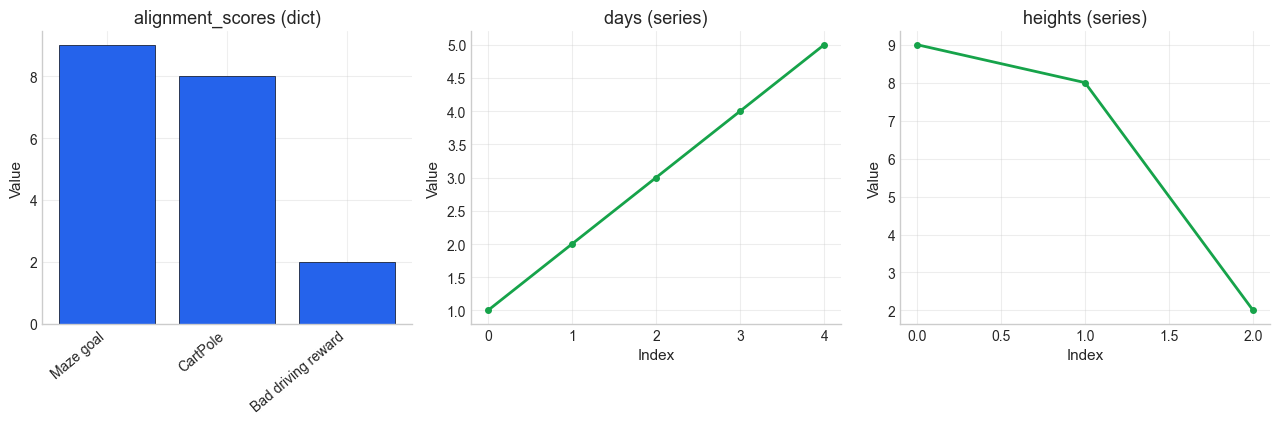

In [9]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Match other Unit 1 notebooks: light grid, readable type, no top/right spines.
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        pass
plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(
        summary.keys(),
        summary.values(),
        color=["#2563eb", "#16a34a", "#f59e0b"],
        edgecolor="#0f172a",
        linewidth=0.65,
    )
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    ax.grid(True, axis="y", alpha=0.35)
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig_w = max(11.0, 4.3 * len(candidates))
    fig, axes = plt.subplots(1, len(candidates), figsize=(fig_w, 4.35))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(
                range(len(values)),
                values,
                color="#2563eb",
                edgecolor="#0f172a",
                linewidth=0.55,
            )
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=40, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
            ax.grid(True, axis="y", alpha=0.35)
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            n = len(payload)
            markevery = max(1, n // 25) if n > 40 else 1
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(
                payload,
                marker="o",
                markersize=4,
                markevery=markevery,
                linewidth=2,
                color="#16a34a",
            )
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
            ax.grid(True, alpha=0.35)
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(
                payload,
                aspect="auto",
                cmap="viridis",
                interpolation="nearest",
            )
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Good RL work begins with problem formulation: choosing a useful state, a realistic action space, and a reward that matches the real goal.

**If students remember one idea:** Many RL failures come from poor problem definition, not from the algorithm itself.

**Quick check before moving on:**
- Can you redesign a bad reward so it better reflects the true objective?
- Can you explain why missing state information can make learning impossible?

**Bridge to the next step:** The mini-project lesson shows how these design choices appear in practical RL experiments.

**For weaker coders:** Pick one story (robot, game, trading). Write state, action, and reward as one plain English sentence each—if you can, you are doing RL design correctly.


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
